In [1]:
import os
# Change to MultiBench directory
os.chdir('MultiBench')

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load audio modality
with open('data/exported_modalities/mosi_audio.pkl', 'rb') as f:
    audio_data = pickle.load(f)

print("AUDIO MODALITY DIMENSIONS")
print("=" * 70)
print(f"Train:  {audio_data['train']['data'].shape}  |  Labels: {audio_data['train']['labels'].shape}")
print(f"Valid:  {audio_data['valid']['data'].shape}  |  Labels: {audio_data['valid']['labels'].shape}")
print(f"Test:   {audio_data['test']['data'].shape}  |  Labels: {audio_data['test']['labels'].shape}")

print(f"\nFeature Dimension: {audio_data['train']['data'].shape[2]} (COVAREP acoustic features)")
print(f"Sequence Length: {audio_data['train']['data'].shape[1]}")
print(f"\nNote: 74 features include pitch, voicing, spectral features, and prosody")

# Show sentiment classes and counts
print("\n\nSENTIMENT CLASSES (7 Classes: -3 to +3)")
print("=" * 70)

splits = ['train', 'valid', 'test']
sentiments = list(range(-3, 4))

for split in splits:
    labels = audio_data[split]['labels'].flatten()
    print(f"\n{split.upper()}:")
    
    for sentiment in sentiments:
        count = int(np.sum((labels > sentiment - 0.5) & (labels <= sentiment + 0.5)))
        percentage = (count / len(labels)) * 100
        print(f"  Sentiment {sentiment:+2d}: {count:>4} samples ({percentage:>5.1f}%)")
    
    print(f"  Range: [{labels.min():.2f}, {labels.max():.2f}]")

AUDIO MODALITY DIMENSIONS
Train:  (1283, 50, 74)  |  Labels: (1283, 1, 1)
Valid:  (214, 50, 74)  |  Labels: (214, 1, 1)
Test:   (686, 50, 74)  |  Labels: (686, 1, 1)

Feature Dimension: 74 (COVAREP acoustic features)
Sequence Length: 50

Note: 74 features include pitch, voicing, spectral features, and prosody


SENTIMENT CLASSES (7 Classes: -3 to +3)

TRAIN:
  Sentiment -3:   25 samples (  1.9%)
  Sentiment -2:  198 samples ( 15.4%)
  Sentiment -1:  241 samples ( 18.8%)
  Sentiment +0:  233 samples ( 18.2%)
  Sentiment +1:  229 samples ( 17.8%)
  Sentiment +2:  311 samples ( 24.2%)
  Sentiment +3:   46 samples (  3.6%)
  Range: [-3.00, 3.00]

VALID:
  Sentiment -3:    8 samples (  3.7%)
  Sentiment -2:   25 samples ( 11.7%)
  Sentiment -1:   26 samples ( 12.1%)
  Sentiment +0:   48 samples ( 22.4%)
  Sentiment +1:   39 samples ( 18.2%)
  Sentiment +2:   49 samples ( 22.9%)
  Sentiment +3:   19 samples (  8.9%)
  Range: [-3.00, 3.00]

TEST:
  Sentiment -3:   47 samples (  6.9%)
  Sentim

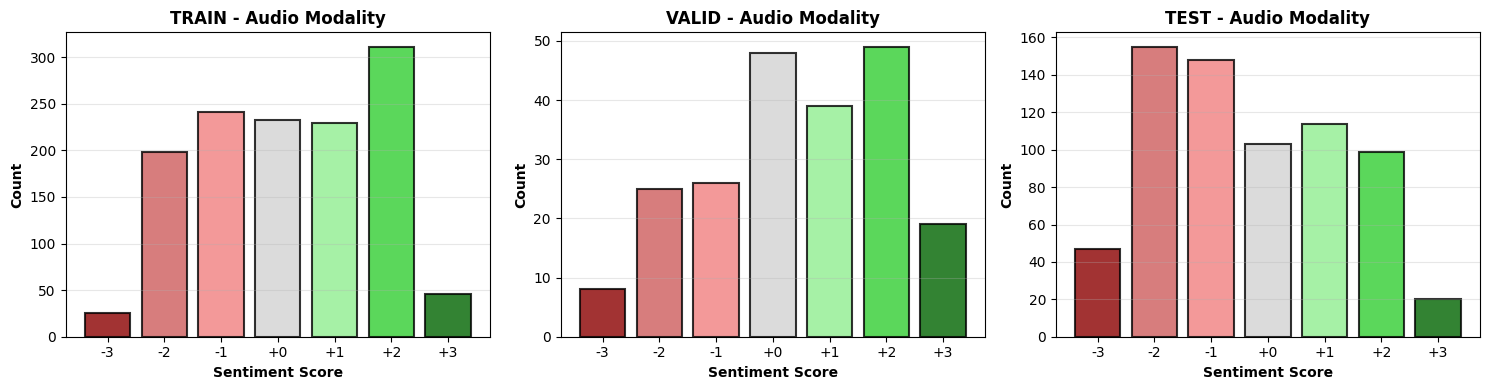

In [4]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sentiments = list(range(-3, 4))
colors = ['#8b0000', '#cd5c5c', '#f08080', '#d3d3d3', '#90ee90', '#32cd32', '#006400']

for idx, split in enumerate(splits):
    labels = audio_data[split]['labels'].flatten()
    
    counts = []
    for sentiment in sentiments:
        count = int(np.sum((labels > sentiment - 0.5) & (labels <= sentiment + 0.5)))
        counts.append(count)
    
    axes[idx].bar(sentiments, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[idx].set_xlabel('Sentiment Score', fontweight='bold')
    axes[idx].set_ylabel('Count', fontweight='bold')
    axes[idx].set_title(f'{split.upper()} - Audio Modality', fontweight='bold')
    axes[idx].set_xticks(sentiments)
    axes[idx].set_xticklabels([f'{s:+d}' for s in sentiments])
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Convert labels to binary (Positive: >0 = 1, Non-positive: ≤0 = 0)
def convert_to_binary(labels):
    return (labels > 0).astype(np.float32).flatten()

# Prepare binary labels
train_labels_binary = convert_to_binary(audio_data['train']['labels'])
valid_labels_binary = convert_to_binary(audio_data['valid']['labels'])
test_labels_binary = convert_to_binary(audio_data['test']['labels'])

print("Binary Label Distribution:")
print("=" * 70)
for split_name, labels in [('TRAIN', train_labels_binary), 
                            ('VALID', valid_labels_binary), 
                            ('TEST', test_labels_binary)]:
    pos = int(labels.sum())
    neg = int(len(labels) - pos)
    print(f"{split_name:<10} Positive (1): {pos:<5} | Negative (0): {neg:<5} | Ratio: {pos/(pos+neg):.2f}")

# Clean audio data: handle NaN/Inf values
def clean_data(data):
    """Replace NaN and Inf values with 0"""
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    return data

# Check and clean audio data
print("\n" + "=" * 70)
print("DATA VALIDATION")
print("=" * 70)
for split in ['train', 'valid', 'test']:
    data = audio_data[split]['data']
    nan_count = np.isnan(data).sum()
    inf_count = np.isinf(data).sum()
    print(f"{split.upper():<10} NaN: {nan_count:<6} Inf: {inf_count:<6}")
    if nan_count > 0 or inf_count > 0:
        print(f"  ⚠ Cleaning {nan_count + inf_count} invalid values...")
        audio_data[split]['data'] = clean_data(data)

# Create PyTorch datasets
train_dataset = TensorDataset(
    torch.FloatTensor(audio_data['train']['data']),
    torch.FloatTensor(train_labels_binary)
)
valid_dataset = TensorDataset(
    torch.FloatTensor(audio_data['valid']['data']),
    torch.FloatTensor(valid_labels_binary)
)
test_dataset = TensorDataset(
    torch.FloatTensor(audio_data['test']['data']),
    torch.FloatTensor(test_labels_binary)
)

# Create DataLoaders (reduce batch size to avoid memory issues)
batch_size = 32  # Reduced from 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ DataLoaders created (batch_size={batch_size})")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Random seed: 42 (for reproducibility)")

h:\Programs\Anaconda\envs\multimodal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Binary Label Distribution:
TRAIN      Positive (1): 678   | Negative (0): 605   | Ratio: 0.53
VALID      Positive (1): 123   | Negative (0): 91    | Ratio: 0.57
TEST       Positive (1): 277   | Negative (0): 409   | Ratio: 0.40

DATA VALIDATION
TRAIN      NaN: 0      Inf: 3     
  ⚠ Cleaning 3 invalid values...
VALID      NaN: 0      Inf: 1     
  ⚠ Cleaning 1 invalid values...
TEST       NaN: 0      Inf: 27    
  ⚠ Cleaning 27 invalid values...

✓ DataLoaders created (batch_size=32)
  Train batches: 40
  Valid batches: 7
  Test batches: 22
  Random seed: 42 (for reproducibility)


In [6]:
# Audio Unimodal Model (TFN Architecture)
class AudioUnimodalTFN(nn.Module):
    def __init__(self, input_dim=74, lstm_hidden=128, embed_dim=128, dropout=0.2):
        super(AudioUnimodalTFN, self).__init__()
        
        # 1. LSTM for temporal modeling of acoustic features
        self.lstm = nn.LSTM(input_dim, lstm_hidden, batch_first=True, 
                           bidirectional=False, dropout=0.0)
        self.lstm_ln = nn.LayerNorm(lstm_hidden)
        
        # 2. Audio Embedding Subnetwork (U_a) - 2 hidden layers with BatchNorm
        self.embed_net = nn.Sequential(
            nn.Linear(lstm_hidden, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # 3. Sentiment Inference Subnetwork (U_s) - Binary classification
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim=74)
        
        # LSTM encoding for temporal acoustic features
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use last hidden state with layer normalization
        last_hidden = self.lstm_ln(h_n[-1])
        
        # Audio embedding
        z_a = self.embed_net(last_hidden)
        
        # Binary classification
        output = self.classifier(z_a)
        
        return output.squeeze()

# Initialize model
# Use CPU to avoid CUDA errors (can switch to 'cuda' if GPU is stable)
device = torch.device('cpu')  # Changed from cuda to cpu for stability
print(f"⚠ Using CPU instead of GPU to avoid CUDA errors")
print(f"  (Training will be slower but more stable)")

model = AudioUnimodalTFN(input_dim=74, lstm_hidden=128, embed_dim=128, dropout=0.2)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01, betas=(0.9, 0.999))

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, 
                                                  patience=3, verbose=True, min_lr=1e-6)

print("\n✓ Audio Unimodal Model initialized (TFN Architecture)")
print(f"  Device: {device}")
print(f"  Input: 74 acoustic features (COVAREP)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Optimizer: AdamW with ReduceLROnPlateau scheduler")
print("\nModel Architecture:")
print(model)

⚠ Using CPU instead of GPU to avoid CUDA errors
  (Training will be slower but more stable)

✓ Audio Unimodal Model initialized (TFN Architecture)
  Device: cpu
  Input: 74 acoustic features (COVAREP)
  Parameters: 163,457
  Optimizer: AdamW with ReduceLROnPlateau scheduler

Model Architecture:
AudioUnimodalTFN(
  (lstm): LSTM(74, 128, batch_first=True)
  (lstm_ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (embed_net): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momen

In [7]:
# Model Summary using torchinfo (better for LSTM models)
try:
    from torchinfo import summary
    
    seq_len = audio_data['train']['data'].shape[1] 
    input_dim = audio_data['train']['data'].shape[2]  
    batch_size_summary = 2  
    
    print("=" * 70)
    print("MODEL SUMMARY")
    print("=" * 70)
    
    summary(model, 
            input_size=(batch_size_summary, seq_len, input_dim),
            device=str(device),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            row_settings=["var_names"],
            verbose=1)
    
except ImportError:
    print("⚠ torchinfo not installed. Installing...")
    print("Run: pip install torchinfo")
    print("\nAlternatively, here's a manual parameter count:")
    print("=" * 70)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nTotal Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-trainable Parameters: {total_params - trainable_params:,}")
    
    print("\nLayer-wise Parameter Count:")
    print("-" * 70)
    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters())
        print(f"{name:<20} {params:>15,} parameters")
    print("=" * 70)

MODEL SUMMARY
Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
AudioUnimodalTFN (AudioUnimodalTFN)      [2, 50, 74]               [2]                       --                        True
├─LSTM (lstm)                            [2, 50, 74]               [2, 50, 128]              104,448                   True
├─LayerNorm (lstm_ln)                    [2, 128]                  [2, 128]                  256                       True
├─Sequential (embed_net)                 [2, 128]                  [2, 128]                  --                        True
│    └─Linear (0)                        [2, 128]                  [2, 128]                  16,512                    True
│    └─BatchNorm1d (1)                   [2, 128]                  [2, 128]                  256                       True
│    └─ReLU (2)                          [2, 128]                  [2, 128]                  --                  

In [7]:
# Training and evaluation functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_data, batch_labels in loader:
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)
        
        # Check for NaN/Inf in batch
        if torch.isnan(batch_data).any() or torch.isinf(batch_data).any():
            print("⚠ Skipping batch with NaN/Inf values")
            continue
        
        optimizer.zero_grad()
        outputs = model(batch_data)
        
        # Check for NaN in outputs
        if torch.isnan(outputs).any() or torch.isinf(outputs).any():
            print("⚠ Model produced NaN/Inf outputs, skipping batch")
            continue
        
        loss = criterion(outputs, batch_labels)
        
        # Check for NaN loss
        if torch.isnan(loss):
            print("⚠ NaN loss detected, skipping batch")
            continue
            
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())
    
    if len(all_preds) == 0:
        return 0.0, 0.0, 0.0
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    return avg_loss, accuracy, f1

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_data, batch_labels in loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            
            # Skip invalid batches
            if torch.isnan(batch_data).any() or torch.isinf(batch_data).any():
                continue
            
            outputs = model(batch_data)
            
            # Skip if model produces invalid outputs
            if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                continue
            
            loss = criterion(outputs, batch_labels)
            
            total_loss += loss.item()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    
    if len(all_preds) == 0:
        return 0.0, 0.0, 0.0, [], []
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    return avg_loss, accuracy, f1, all_preds, all_labels

print("✓ Training functions defined (with gradient clipping and NaN protection)")


✓ Training functions defined (with gradient clipping and NaN protection)


In [8]:
# Training loop
num_epochs = 100
best_val_f1 = 0
best_val_acc = 0
patience = 15
patience_counter = 0

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [],
    'lr': []
}

print("=" * 70)
print("TRAINING AUDIO UNIMODAL MODEL (TFN)")
print("=" * 70)
print(f"Epochs: {num_epochs} | Batch Size: {batch_size} | Initial LR: 1e-3")
print(f"Dropout: 0.2 | L2 Weight Decay: 0.01 | Optimizer: AdamW")
print(f"Scheduler: ReduceLROnPlateau | Early Stopping Patience: {patience}")
print(f"Gradient Clipping: 1.0 | Device: {device}")
print("=" * 70)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, valid_loader, criterion, device)
    
    # Update learning rate scheduler
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
              f"LR: {current_lr:.6f}")
    
    # Save best model based on F1 score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        torch.save({ 
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc
        }, 'best_audio_unimodal.pt')
        patience_counter = 0
        print(f"  ✓ New best model saved! (Val F1: {val_f1:.4f}, Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    # Stop if learning rate is too small
    if current_lr < 1e-6:
        print(f"\nStopping: Learning rate too small ({current_lr:.2e})")
        break

print("=" * 70)
print(f"✓ Training completed!")
print(f"  Best Validation F1: {best_val_f1:.4f}")
print(f"  Best Validation Accuracy: {best_val_acc:.4f}")
print(f"  Total Epochs: {epoch + 1}")
print("=" * 70)

TRAINING AUDIO UNIMODAL MODEL (TFN)
Epochs: 100 | Batch Size: 32 | Initial LR: 1e-3
Dropout: 0.2 | L2 Weight Decay: 0.01 | Optimizer: AdamW
Scheduler: ReduceLROnPlateau | Early Stopping Patience: 15
Gradient Clipping: 1.0 | Device: cpu
Epoch [  1/100] | Train Loss: 0.7637 Acc: 0.5367 F1: 0.5545 | Val Loss: 0.7119 Acc: 0.5421 F1: 0.6260 | LR: 0.001000
  ✓ New best model saved! (Val F1: 0.6260, Val Acc: 0.5421)
Epoch [  1/100] | Train Loss: 0.7637 Acc: 0.5367 F1: 0.5545 | Val Loss: 0.7119 Acc: 0.5421 F1: 0.6260 | LR: 0.001000
  ✓ New best model saved! (Val F1: 0.6260, Val Acc: 0.5421)
  ✓ New best model saved! (Val F1: 0.6447, Val Acc: 0.5467)
  ✓ New best model saved! (Val F1: 0.6447, Val Acc: 0.5467)
Epoch [  5/100] | Train Loss: 0.7148 Acc: 0.5484 F1: 0.5930 | Val Loss: 0.7146 Acc: 0.5234 F1: 0.6331 | LR: 0.001000
Epoch [  5/100] | Train Loss: 0.7148 Acc: 0.5484 F1: 0.5930 | Val Loss: 0.7146 Acc: 0.5234 F1: 0.6331 | LR: 0.001000
Epoch 00006: reducing learning rate of group 0 to 5.0000

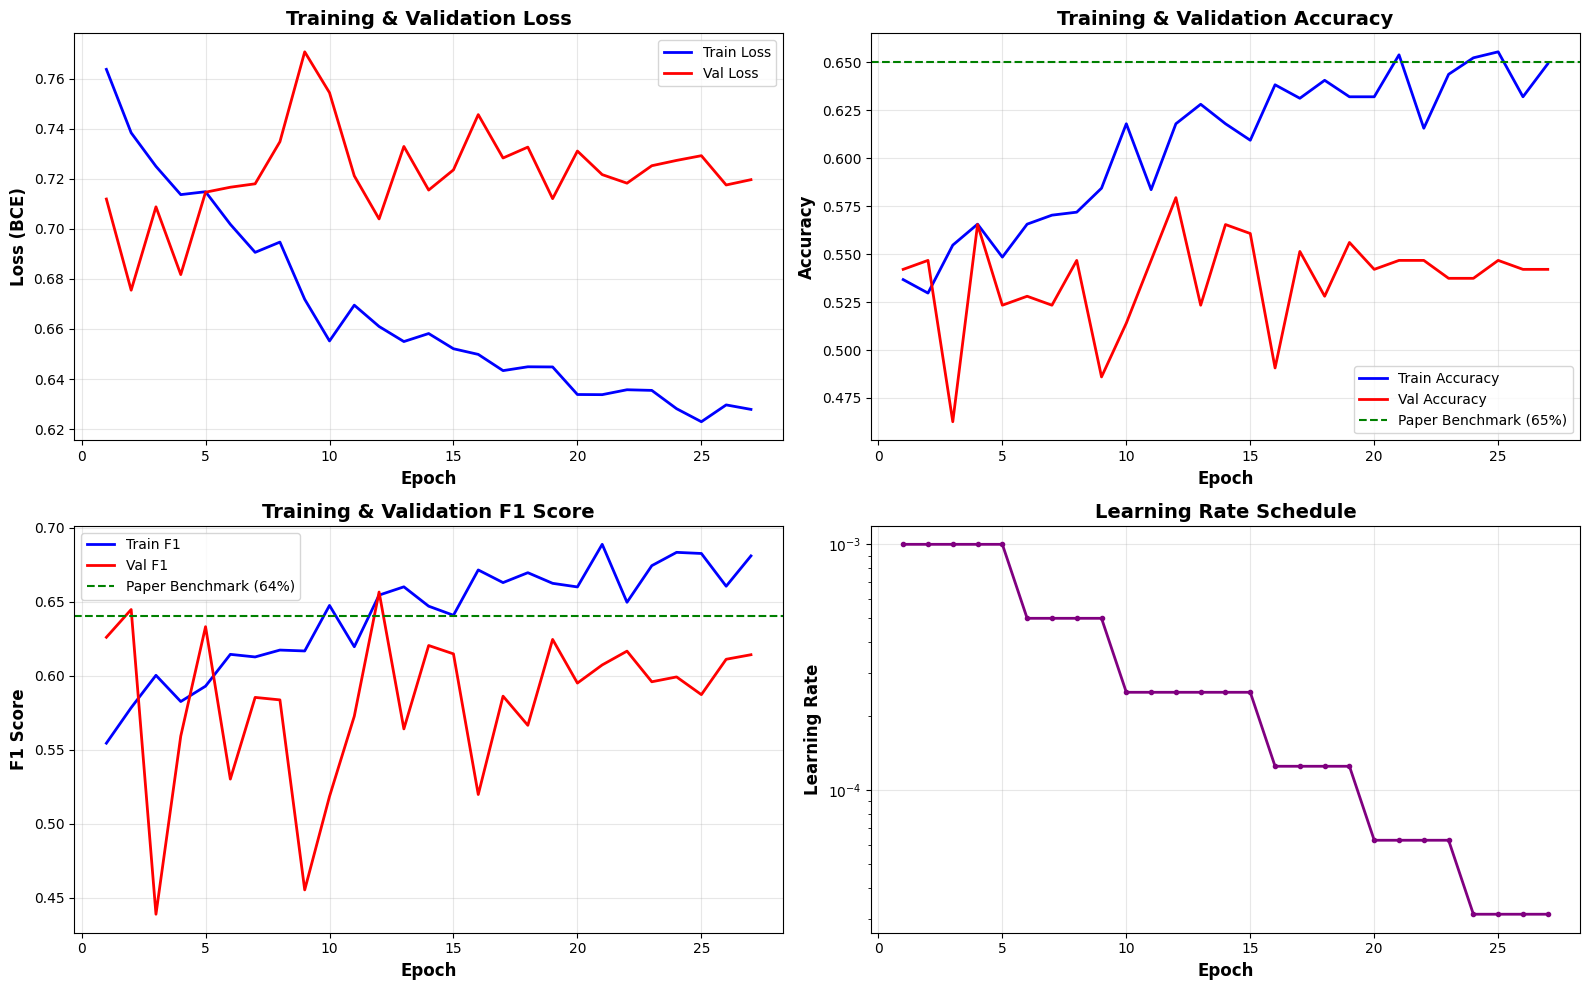

In [11]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Loss (BCE)', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
axes[0, 1].axhline(y=0.65, color='g', linestyle='--', label='Paper Benchmark (65%)', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Training & Validation Accuracy', fontweight='bold', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score curves
axes[1, 0].plot(epochs_range, history['train_f1'], 'b-', label='Train F1', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_f1'], 'r-', label='Val F1', linewidth=2)
axes[1, 0].axhline(y=0.64, color='g', linestyle='--', label='Paper Benchmark (64%)', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('F1 Score', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Training & Validation F1 Score', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate Schedule
axes[1, 1].plot(epochs_range, history['lr'], 'purple', linewidth=2, marker='o', markersize=3)
axes[1, 1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold', fontsize=14)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TEST SET RESULTS (Audio Unimodal - TFN)
Test Loss:     0.7305
Test Accuracy: 0.4985 (49.85%)
Test F1 Score: 0.5339

Comparison with TFN Paper (Zadeh et al., 2017):
----------------------------------------------------------------------
Metric               Our Model       Paper           Difference     
----------------------------------------------------------------------
Accuracy             0.4985 (49.9%)    0.6500 (65.0%)    -15.1%
F1 Score             0.5339           0.6400           -10.6%
----------------------------------------------------------------------

📌 Model loaded from checkpoint:
   Best epoch: 12
   Validation F1: 0.6565
   Validation Acc: 0.5794
----------------------------------------------------------------------
⚠ Results differ from paper. Consider adjusting hyperparameters or random seed.

Detailed Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

Negative (0)   

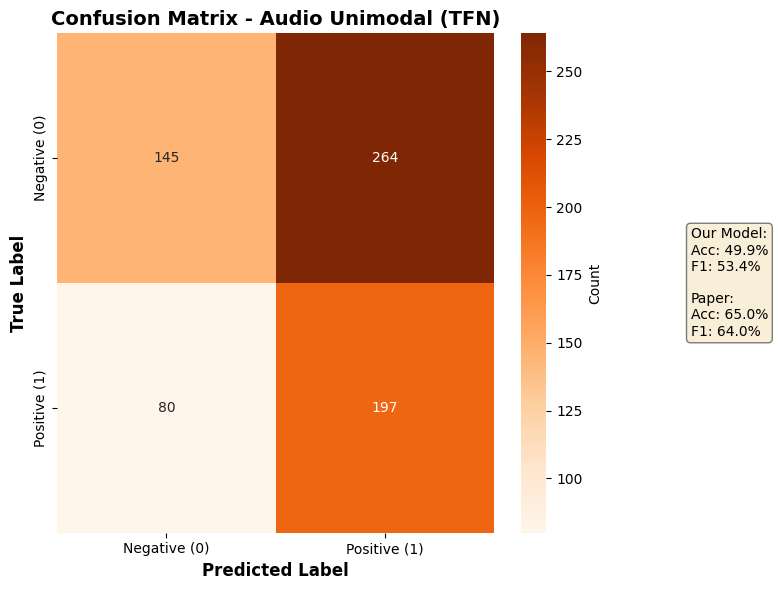


✓ Test evaluation completed!


In [10]:
# Load best model and evaluate on test set
checkpoint = torch.load('best_audio_unimodal.pt')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

# TFN Paper benchmark
paper_acc = 0.65  # 65%
paper_f1 = 0.64   # 64%

print("\n" + "=" * 70)
print("TEST SET RESULTS (Audio Unimodal - TFN)")
print("=" * 70)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test F1 Score: {test_f1:.4f}")
print("=" * 70)

print("\nComparison with TFN Paper (Zadeh et al., 2017):")
print("-" * 70)
print(f"{'Metric':<20} {'Our Model':<15} {'Paper':<15} {'Difference':<15}")
print("-" * 70)
print(f"{'Accuracy':<20} {test_acc:.4f} ({test_acc*100:.1f}%){'':<3} {paper_acc:.4f} ({paper_acc*100:.1f}%){'':<3} {(test_acc-paper_acc)*100:+.1f}%")
print(f"{'F1 Score':<20} {test_f1:.4f}{'':<10} {paper_f1:.4f}{'':<10} {(test_f1-paper_f1)*100:+.1f}%")
print("-" * 70)

# Show checkpoint info
print(f"\n📌 Model loaded from checkpoint:")
print(f"   Best epoch: {checkpoint['epoch'] + 1}")
print(f"   Validation F1: {checkpoint['val_f1']:.4f}")
print(f"   Validation Acc: {checkpoint['val_acc']:.4f}")
print("-" * 70)

if abs(test_acc - paper_acc) < 0.03 and abs(test_f1 - paper_f1) < 0.03:
    print("✓ Results are within expected range of paper benchmarks!")
elif test_acc > paper_acc and test_f1 > paper_f1:
    print("✓ Results exceed paper benchmarks!")
else:
    print("⚠ Results differ from paper. Consider adjusting hyperparameters or random seed.")

print("\nDetailed Classification Report:")
print("-" * 70)
print(classification_report(test_labels, test_preds, 
                          target_names=['Negative (0)', 'Positive (1)'],
                          digits=4))

# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title('Confusion Matrix - Audio Unimodal (TFN)', fontweight='bold', fontsize=14)

# Add benchmark comparison on plot
textstr = f'Our Model:\nAcc: {test_acc*100:.1f}%\nF1: {test_f1*100:.1f}%\n\nPaper:\nAcc: {paper_acc*100:.1f}%\nF1: {paper_f1*100:.1f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(1.45, 0.5, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=props)

plt.tight_layout()
plt.show()

print(f"\n✓ Test evaluation completed!")